In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pahdehrek/names4makemore/names.txt


In [2]:
with open('/kaggle/input/datasets/pahdehrek/names4makemore/names.txt','r') as wordsfile:
    words = wordsfile.read().splitlines()
chars = sorted(list(set(''.join(words))))
itos = {i+1:s for i,s in enumerate(chars)}
itos[0] = '.'
stoi = {s:i for i,s in itos.items()}
vocab_size = len(itos)
print(f'{vocab_size=}')

vocab_size=27


In [3]:
block_size = 3 #context len

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
                           

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [4]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        
        #parameters (which are trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
        #buffers (which are trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        # forward passssssss
        if self.training:
            xmean = x.mean(0, keepdim=True) #batch mean
            xvar = x.var(0, keepdim=True) #batch var
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) #normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        #update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(92734) #reproducibility

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [
    Linear(n_embd*block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size, bias=False),
    BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    #all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(f'no.parameters = {sum(p.nelement() for p in parameters)}') #no. parameters
for p in parameters:
    p.requires_grad = True

no.parameters = 47024


In [5]:
#same optimization

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix] #batch X,Y

    #forward passsss
    emb = C[Xb] #now we have embedded the characters into vectors
    x = emb.view(emb.shape[0], -1) #concat
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) #loss function

    #backward passssssss
    for layer in layers:#**************************
        layer.out.retain_grad() #TAKE OUT AFTER DEBUGGGGGG
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.05 if i<150000 else 0.01 #lr decay
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i%10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}') #why would he do :7d here?? doesnt make any sense
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    # if i >= 10000: #************************
    #     break #TAKE OUT AFTER DEBUG

      0/ 200000: 3.2916
  10000/ 200000: 2.3404
  20000/ 200000: 2.7952
  30000/ 200000: 2.7195
  40000/ 200000: 2.3861
  50000/ 200000: 2.3575
  60000/ 200000: 2.3972
  70000/ 200000: 1.9772
  80000/ 200000: 1.9674
  90000/ 200000: 2.1693
 100000/ 200000: 2.0134
 110000/ 200000: 2.2682
 120000/ 200000: 2.1582
 130000/ 200000: 2.1107
 140000/ 200000: 2.2648
 150000/ 200000: 2.3870
 160000/ 200000: 1.7172
 170000/ 200000: 2.2977
 180000/ 200000: 2.0144
 190000/ 200000: 1.8974


layer 2 (      Tanh): mean +0.01, std 0.65, saturated: 8.06%
layer 5 (      Tanh): mean -0.02, std 0.69, saturated: 10.56%
layer 8 (      Tanh): mean -0.01, std 0.71, saturated: 9.97%
layer 11 (      Tanh): mean +0.00, std 0.71, saturated: 10.06%
layer 14 (      Tanh): mean +0.01, std 0.73, saturated: 11.31%


/tmp/ipykernel_16/2388579203.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs()>0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

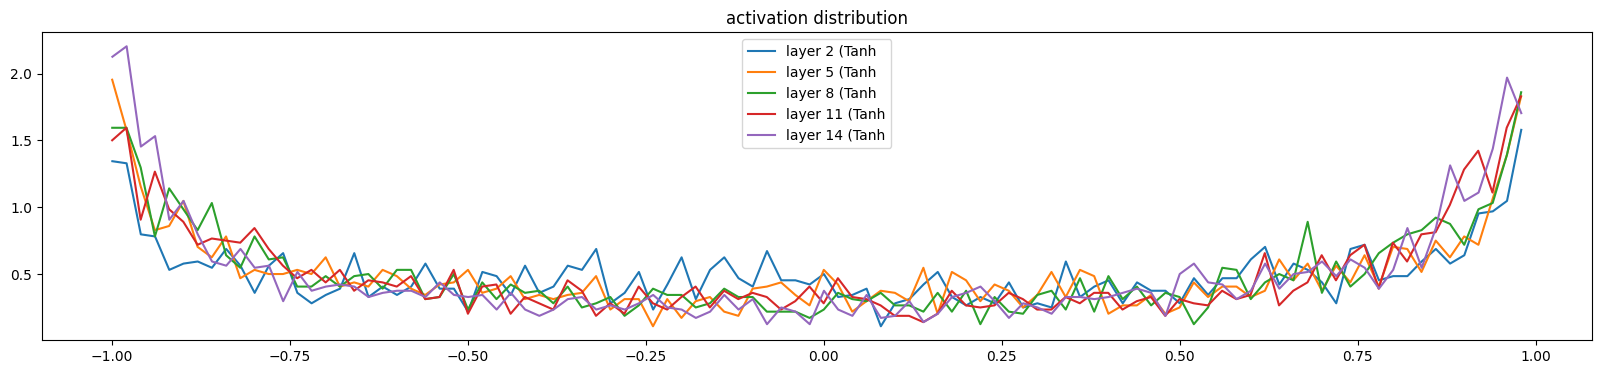

In [6]:
#visualize histograms
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]): #note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs()>0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')


layer 2 (      Tanh): mean -0.000000, std 6.344304e-03
layer 5 (      Tanh): mean +0.000000, std 5.765560e-03
layer 8 (      Tanh): mean -0.000000, std 5.728474e-03
layer 11 (      Tanh): mean +0.000000, std 5.477038e-03
layer 14 (      Tanh): mean +0.000000, std 5.274729e-03


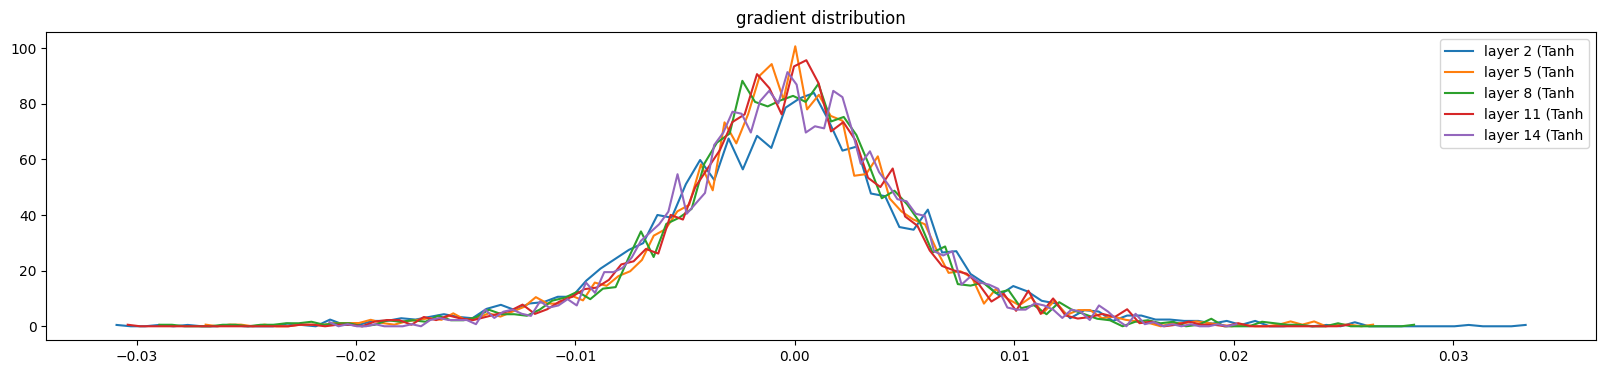

In [7]:
#another visualize histograms??
plt.figure(figsize=(20,4))
legends = []
for i,layer in enumerate(layers[:-1]): #note: exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
    plt.legend(legends)
    plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 2.227451e-02 | grad:data ratio 2.079324e-02
weight  (30, 100) | mean +0.000022 | std 8.807971e-03 | grad:data ratio 1.560831e-02
weight (100, 100) | mean +0.000007 | std 7.164063e-03 | grad:data ratio 2.239564e-02
weight (100, 100) | mean +0.000071 | std 7.259438e-03 | grad:data ratio 2.255337e-02
weight (100, 100) | mean -0.000002 | std 6.969903e-03 | grad:data ratio 2.209317e-02
weight (100, 100) | mean +0.000100 | std 6.487036e-03 | grad:data ratio 2.074884e-02
weight  (100, 27) | mean -0.000176 | std 1.105347e-02 | grad:data ratio 3.092015e-02


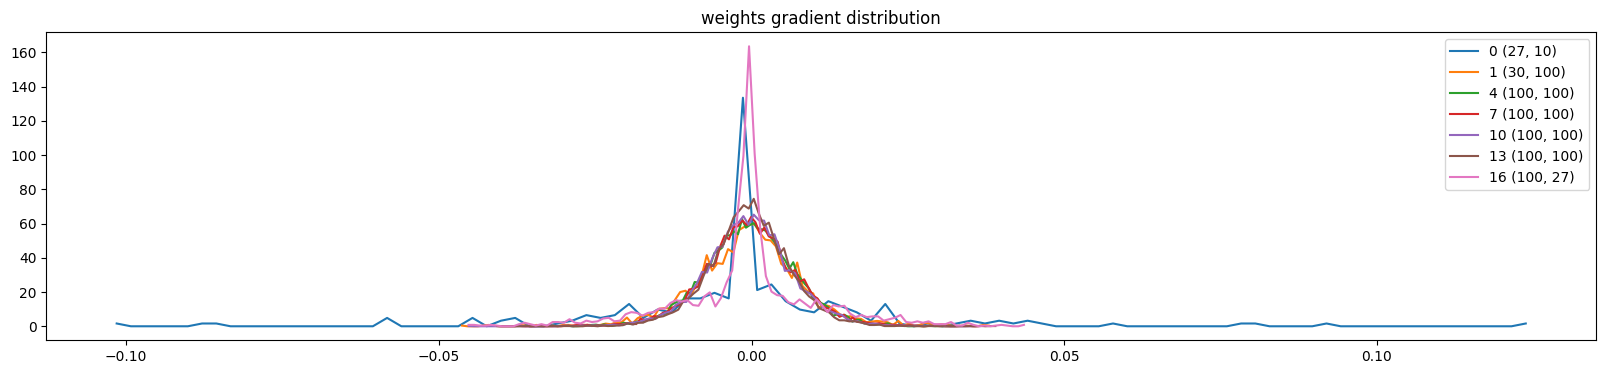

In [8]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
    plt.legend(legends)
    plt.title('weights gradient distribution')

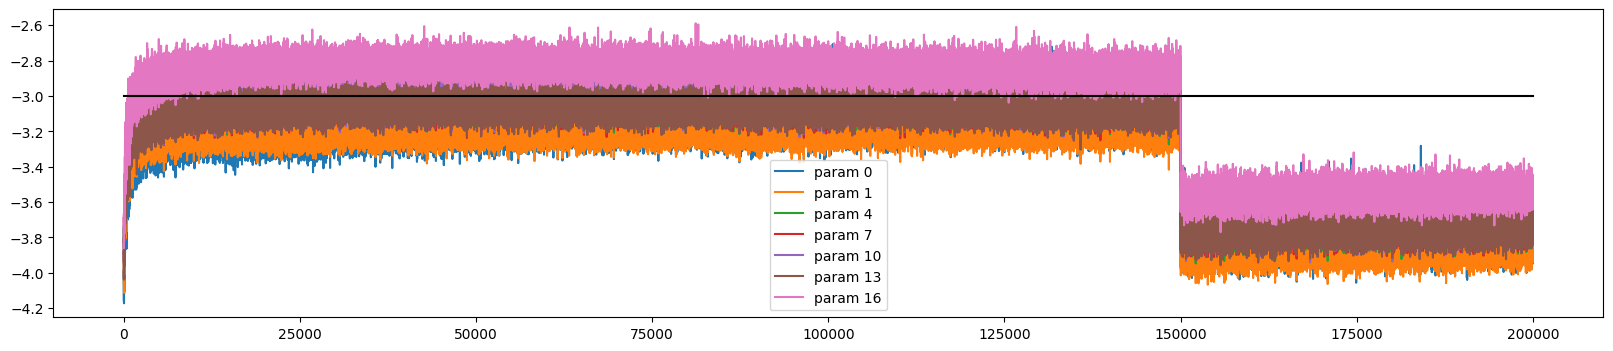

In [9]:
plt.figure(figsize = (20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0,len(ud)], [-3,-3], 'k')
plt.legend(legends)

In [10]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,y)
    print(split, loss.item())

#put layers into eval mode
for layer in layers:
    layer.training = False
split_loss('train')
split_loss('val')

train 2.036864757537842
val 2.0958609580993652


In [11]:
g = torch.Generator().manual_seed(23948)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        #forward pass the neural nettt!
        emb = C[torch.tensor([context])] #(1,block_size,n_embd)
        x = emb.view(emb.shape[0], -1) #concat
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        #sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        #shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0: #sampled '.', break
            break

    print(''.join(itos[i] for i in out if i != 0))

rodidy
lora
ariani
ambert
torie
kenna
rhyatalibeptorri
ath
auriama
kaishaydin
char
muzleigh
kamin
patalexe
hika
juelyn
yas
kaycea
semyler
jermontelaniry


In [12]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));

interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

In [13]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [14]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g)  / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  0.03164403513073921
x std:  0.9806987643241882
out std:  0.9999947547912598
------
out grad std:  0.9782556295394897
x grad std:  0.997502863407135
w grad std:  0.9856599569320679
inp grad std:  0.9953001737594604
